# Phase 1 — EDA & Preprocessing

**Timeseries:** `596eef7c71f933d820d0e485935d0e8f` | Beauty & Fitness / Hair Care | US | USD

Steps covered:
1. Load & validate data
2. Date continuity check
3. KPI over time
4. Channel spend over time
5. Correlation analysis
6. Distribution analysis
7. Preprocessing pipeline (`mmm/preprocessing.py`)

In [8]:
import sys
import os

# Make the mmm package importable from the notebooks/ subdirectory
sys.path.insert(0, os.path.join(os.path.dirname(os.getcwd()), ""))
sys.path.insert(0, os.path.abspath(".."))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

pd.set_option("display.max_columns", None)
plt.rcParams["figure.figsize"] = (14, 4)
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

print("Imports OK")

Imports OK


## 1. Load & Validate

In [9]:
from mmm.preprocessing import load_timeseries, TIMESERIES_ID

df = load_timeseries("../data/mmm_data.csv")

print(f"Shape:      {df.shape}")
print(f"Date range: {df['date_day'].min().date()} → {df['date_day'].max().date()}")
print(f"Vertical:   {df['organisation_vertical'].iloc[0]} / {df['organisation_subvertical'].iloc[0]}")
print(f"Territory:  {df['organisation_primary_territory_name'].iloc[0]}")
print(f"Currency:   {df['currency_code'].iloc[0]}")
print(f"Sources:    {df['organisation_marketing_sources'].iloc[0]}")
df.head(3)

Shape:      (509, 50)
Date range: 2022-07-29 → 2023-12-19
Vertical:   Beauty & Fitness / Hair Care
Territory:  US
Currency:   USD
Sources:    Google, Meta


,mmm_timeseries_id,organisation_id,organisation_vertical,organisation_subvertical,organisation_marketing_sources,organisation_primary_territory_name,territory_name,date_day,currency_code,first_purchases,first_purchases_units,first_purchases_original_price,first_purchases_gross_discount,all_purchases,all_purchases_units,all_purchases_original_price,all_purchases_gross_discount,google_paid_search_spend,google_shopping_spend,google_pmax_spend,google_display_spend,google_video_spend,meta_facebook_spend,meta_instagram_spend,meta_other_spend,tiktok_spend,google_paid_search_clicks,google_shopping_clicks,google_pmax_clicks,google_display_clicks,google_video_clicks,meta_facebook_clicks,meta_instagram_clicks,meta_other_clicks,tiktok_clicks,google_paid_search_impressions,google_shopping_impressions,google_pmax_impressions,google_display_impressions,google_video_impressions,meta_facebook_impressions,meta_instagram_impressions,meta_other_impressions,tiktok_impressions,direct_clicks,branded_search_clicks,organic_search_clicks,email_clicks,referral_clicks,all_other_clicks
0,596eef7c71f933d820d0e485935d0e8f,04769dac8b828ec7a85676d9e2bffe6f,Beauty & Fitness,Hair Care,"Google, Meta",US,All Territories,2022-07-29,USD,22,27,3837.980834,632.595555,27,32,4552.984240,846.593069,NaN,NaN,205.528905,NaN,NaN,233.75,NaN,NaN,NaN,NaN,NaN,255.0,NaN,NaN,163.0,NaN,NaN,NaN,NaN,NaN,31907.0,NaN,NaN,18997.0,NaN,NaN,NaN,139.0,NaN,300.0,1.0,61.0,40.0
1,596eef7c71f933d820d0e485935d0e8f,04769dac8b828ec7a85676d9e2bffe6f,Beauty & Fitness,Hair Care,"Google, Meta",US,All Territories,2022-07-30,USD,14,21,2747.998631,443.996522,17,26,3177.998032,613.806522,NaN,NaN,277.082025,NaN,NaN,248.84,NaN,NaN,NaN,NaN,NaN,348.0,NaN,NaN,128.0,NaN,NaN,NaN,NaN,NaN,44483.0,NaN,NaN,20188.0,NaN,NaN,NaN,209.0,NaN,442.0,8.0,110.0,62.0
2,596eef7c71f933d820d0e485935d0e8f,04769dac8b828ec7a85676d9e2bffe6f,Beauty & Fitness,Hair Care,"Google, Meta",US,All Territories,2022-07-31,USD,31,39,4567.998818,1185.197966,39,48,5468.998818,1504.997966,NaN,NaN,427.436429,NaN,NaN,274.51,NaN,NaN,NaN,NaN,NaN,405.0,NaN,NaN,148.0,NaN,NaN,NaN,NaN,NaN,58173.0,NaN,NaN,24718.0,NaN,NaN,NaN,262.0,NaN,427.0,631.0,108.0,65.0


## 2. Date Continuity Check

In [10]:
full_range = pd.date_range(df["date_day"].min(), df["date_day"].max(), freq="D")
missing_dates = full_range.difference(df["date_day"])

print(f"Expected days : {len(full_range)}")
print(f"Actual rows   : {len(df)}")
print(f"Missing dates : {len(missing_dates)}")
if len(missing_dates):
    print(missing_dates.tolist())

Expected days : 509
Actual rows   : 509
Missing dates : 0


## 3. KPI Over Time (`all_purchases`)

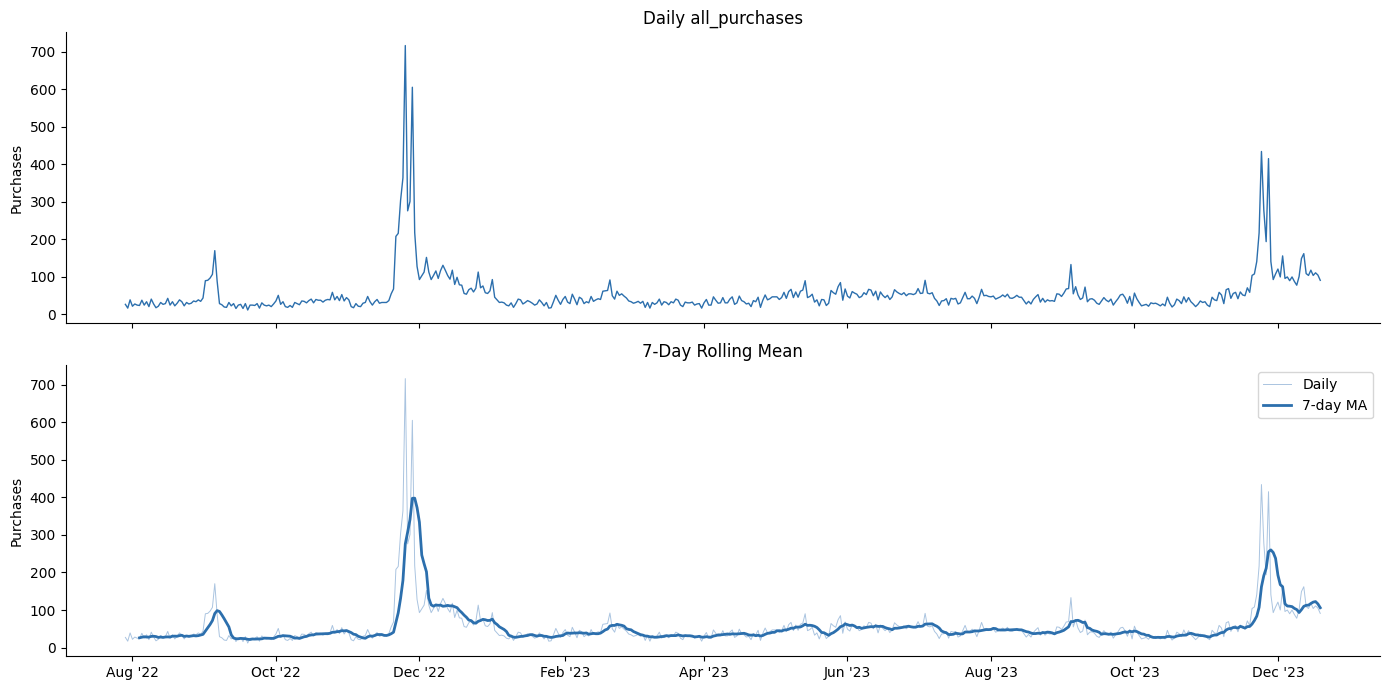


KPI stats:
count    509.0
mean      55.3
std       59.9
min       12.0
25%       31.0
50%       40.0
75%       56.0
max      716.0
Name: all_purchases, dtype: float64


In [11]:
fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)

# Daily KPI
axes[0].plot(df["date_day"], df["all_purchases"], lw=1, color="#2c6fad")
axes[0].set_title("Daily all_purchases", fontsize=12)
axes[0].set_ylabel("Purchases")

# 7-day rolling mean to show trend
rolling = df.set_index("date_day")["all_purchases"].rolling(7).mean()
axes[1].plot(df["date_day"], df["all_purchases"], lw=0.7, color="#aac4e0", label="Daily")
axes[1].plot(rolling.index, rolling.values, lw=2, color="#2c6fad", label="7-day MA")
axes[1].set_title("7-Day Rolling Mean", fontsize=12)
axes[1].set_ylabel("Purchases")
axes[1].legend()
axes[1].xaxis.set_major_formatter(mdates.DateFormatter("%b '%y"))
axes[1].xaxis.set_major_locator(mdates.MonthLocator(interval=2))

plt.tight_layout()
plt.show()

print(f"\nKPI stats:\n{df['all_purchases'].describe().round(1)}")

## 4. Channel Spend Over Time

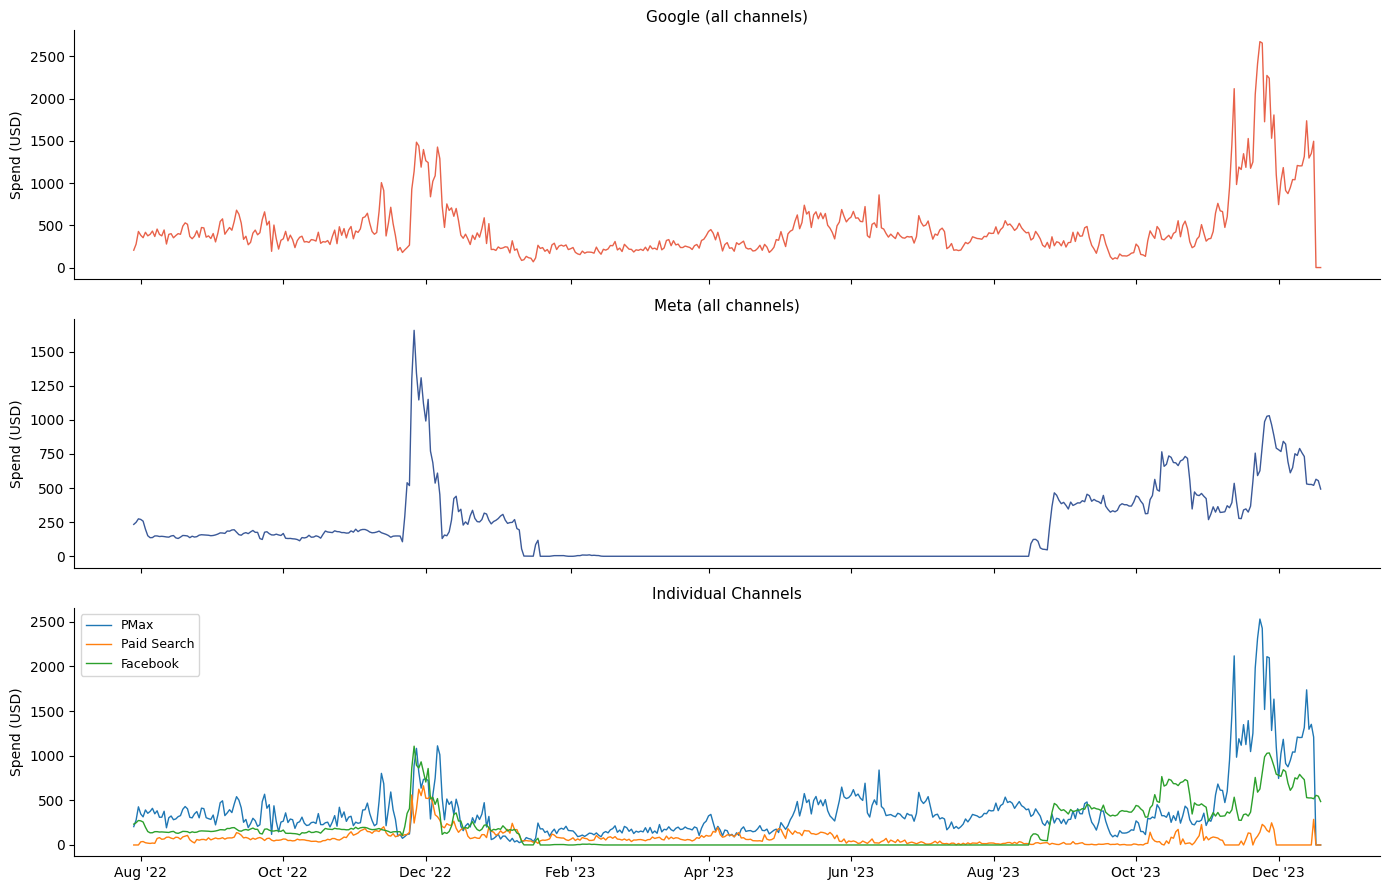


Total spend (full period):
total_google_spend    $234,027
total_meta_spend      $102,546
dtype: str


In [12]:
from mmm.preprocessing import GOOGLE_SPEND_COLS, META_SPEND_COLS

# Fill NaN with 0 for plotting only
plot_df = df.copy()
plot_df[GOOGLE_SPEND_COLS + META_SPEND_COLS] = (
    plot_df[GOOGLE_SPEND_COLS + META_SPEND_COLS].fillna(0)
)

# Aggregate into platform totals
plot_df["total_google_spend"] = plot_df[GOOGLE_SPEND_COLS].sum(axis=1)
plot_df["total_meta_spend"] = plot_df[META_SPEND_COLS].sum(axis=1)

fig, axes = plt.subplots(3, 1, figsize=(14, 9), sharex=True)

channels = {
    "total_google_spend": ("#e8624a", "Google (all channels)"),
    "total_meta_spend":   ("#3b5998", "Meta (all channels)"),
}
individual = {
    "google_pmax_spend":      ("#f4a582", "PMax"),
    "google_paid_search_spend": ("#e8624a", "Paid Search"),
    "meta_facebook_spend":    ("#3b5998", "Facebook"),
}

for ax, (col, (color, label)) in zip(axes[:2], channels.items()):
    ax.plot(plot_df["date_day"], plot_df[col], lw=1, color=color)
    ax.set_title(label, fontsize=11)
    ax.set_ylabel("Spend (USD)")

for col, (color, label) in individual.items():
    axes[2].plot(plot_df["date_day"], plot_df[col], lw=1, label=label)
axes[2].set_title("Individual Channels", fontsize=11)
axes[2].set_ylabel("Spend (USD)")
axes[2].legend(loc="upper left", fontsize=9)
axes[2].xaxis.set_major_formatter(mdates.DateFormatter("%b '%y"))
axes[2].xaxis.set_major_locator(mdates.MonthLocator(interval=2))

plt.tight_layout()
plt.show()

# Total spend summary
total_spend = plot_df[["total_google_spend", "total_meta_spend"]].sum()
print("\nTotal spend (full period):")
print(total_spend.apply(lambda x: f"${x:,.0f}"))

## 5. Correlation Analysis

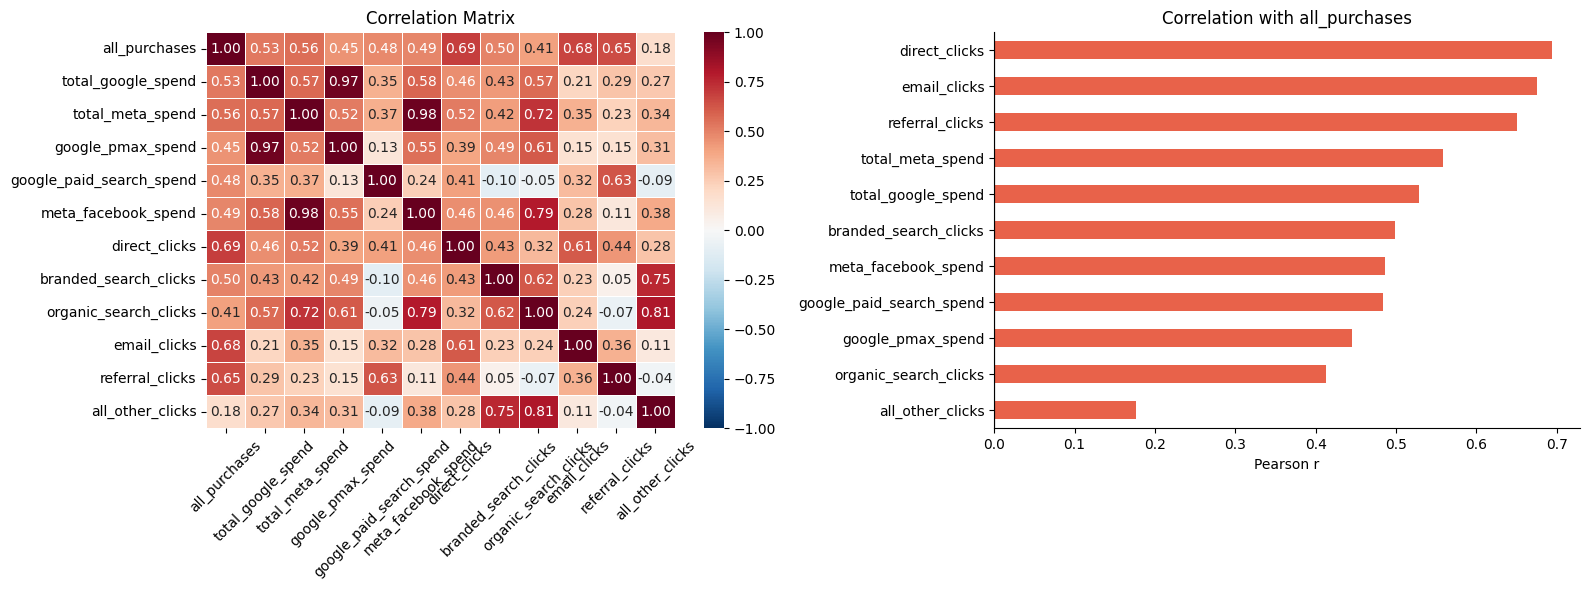

In [13]:
from mmm.preprocessing import CONTROL_COLS

corr_cols = (
    ["all_purchases", "total_google_spend", "total_meta_spend"]
    + ["google_pmax_spend", "google_paid_search_spend", "meta_facebook_spend"]
    + [c for c in CONTROL_COLS if c in plot_df.columns]
)

corr_df = plot_df[corr_cols].copy()
corr_matrix = corr_df.corr()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Full heatmap
sns.heatmap(
    corr_matrix,
    ax=axes[0],
    annot=True,
    fmt=".2f",
    cmap="RdBu_r",
    center=0,
    vmin=-1, vmax=1,
    linewidths=0.5,
)
axes[0].set_title("Correlation Matrix", fontsize=12)
axes[0].tick_params(axis="x", rotation=45)

# Correlation with all_purchases (sorted)
kpi_corr = corr_matrix["all_purchases"].drop("all_purchases").sort_values()
colors = ["#e8624a" if v > 0 else "#3b5998" for v in kpi_corr]
kpi_corr.plot.barh(ax=axes[1], color=colors)
axes[1].axvline(0, color="black", linewidth=0.8)
axes[1].set_title("Correlation with all_purchases", fontsize=12)
axes[1].set_xlabel("Pearson r")

plt.tight_layout()
plt.show()

## 6. Distribution Analysis

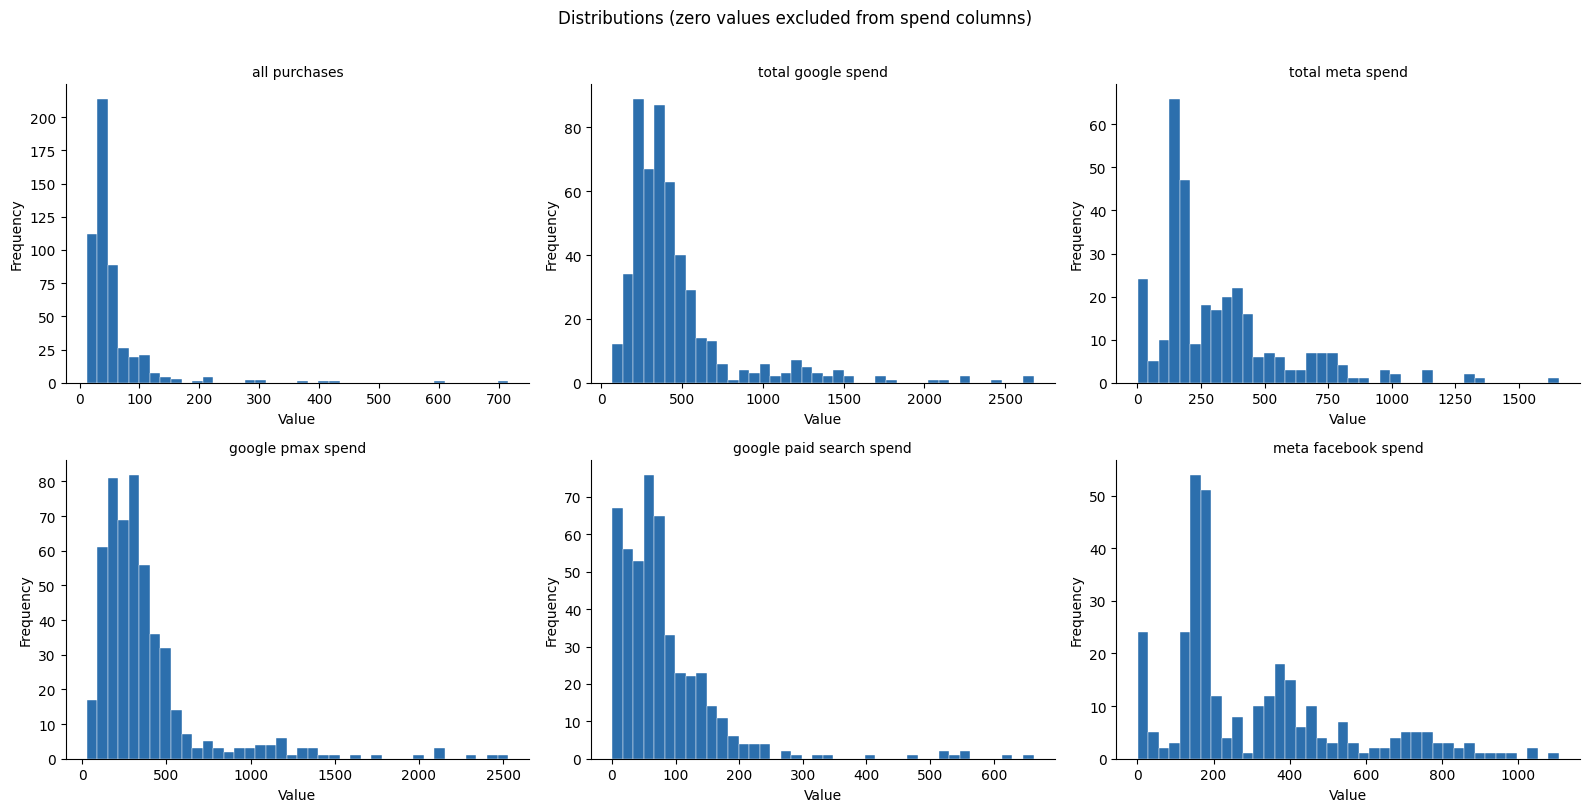


KPI mean: 55.3
KPI var:  3585.9
Var/Mean (dispersion index): 64.81
→ If >> 1, consider NegativeBinomial likelihood in PyMC model


In [14]:
dist_cols = ["all_purchases", "total_google_spend", "total_meta_spend",
             "google_pmax_spend", "google_paid_search_spend", "meta_facebook_spend"]

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()

for ax, col in zip(axes, dist_cols):
    data = plot_df[col].dropna()
    ax.hist(data[data > 0], bins=40, color="#2c6fad", edgecolor="white", linewidth=0.3)
    ax.set_title(col.replace("_", " "), fontsize=10)
    ax.set_xlabel("Value")
    ax.set_ylabel("Frequency")

plt.suptitle("Distributions (zero values excluded from spend columns)", fontsize=12, y=1.01)
plt.tight_layout()
plt.show()

# Check for overdispersion in KPI (relevant for likelihood choice)
kpi = df["all_purchases"]
mean_kpi = kpi.mean()
var_kpi = kpi.var()
print(f"\nKPI mean: {mean_kpi:.1f}")
print(f"KPI var:  {var_kpi:.1f}")
print(f"Var/Mean (dispersion index): {var_kpi/mean_kpi:.2f}")
print("→ If >> 1, consider NegativeBinomial likelihood in PyMC model")

## 7. Preprocessing Pipeline

Run `mmm/preprocessing.prepare_features()` and inspect the result.

In [15]:
from mmm.preprocessing import prepare_features, train_holdout_split

df_clean = prepare_features(df)

print("New columns added by preprocessing:")
new_cols = [c for c in df_clean.columns if c not in df.columns]
for c in new_cols:
    print(f"  {c}")

print(f"\nShape before: {df.shape}")
print(f"Shape after:  {df_clean.shape}")
print(f"\nNull counts after preprocessing:")
nulls = df_clean.isnull().sum()
print(nulls[nulls > 0] if nulls.any() else "  None")

New columns added by preprocessing:
  total_google_spend
  total_meta_spend
  day_of_week
  week_of_year
  month
  is_weekend
  is_holiday
  total_google_spend_log
  total_meta_spend_log

Shape before: (509, 50)
Shape after:  (509, 59)

Null counts after preprocessing:
  None


Train   : 407 rows  (2022-07-29 → 2023-09-08)
Holdout : 102 rows  (2023-09-09 → 2023-12-19)


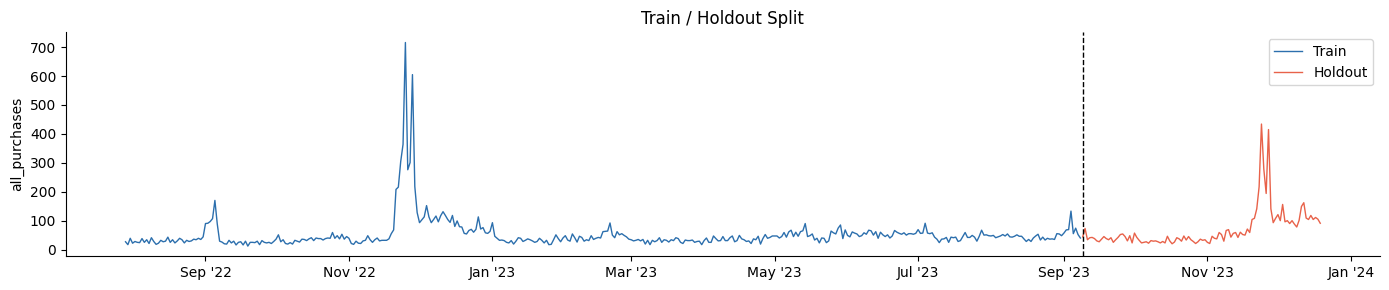


Ready for Phase 2 → notebooks/02-model.ipynb
Save df_clean to use in next notebook:
  Saved: data/mmm_data_clean.csv


In [16]:
train, holdout = train_holdout_split(df_clean)

print(f"Train   : {len(train)} rows  ({train['date_day'].min().date()} → {train['date_day'].max().date()})")
print(f"Holdout : {len(holdout)} rows  ({holdout['date_day'].min().date()} → {holdout['date_day'].max().date()})")

# Visualise the split
fig, ax = plt.subplots(figsize=(14, 3))
ax.plot(train["date_day"], train["all_purchases"], lw=1, color="#2c6fad", label="Train")
ax.plot(holdout["date_day"], holdout["all_purchases"], lw=1, color="#e8624a", label="Holdout")
ax.axvline(holdout["date_day"].iloc[0], color="black", linestyle="--", lw=1)
ax.set_title("Train / Holdout Split", fontsize=12)
ax.set_ylabel("all_purchases")
ax.legend()
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b '%y"))
plt.tight_layout()
plt.show()

print("\nReady for Phase 2 → notebooks/02-model.ipynb")
print(f"Save df_clean to use in next notebook:")
df_clean.to_csv("../data/mmm_data_clean.csv", index=False)
print("  Saved: data/mmm_data_clean.csv")